In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [4]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


# Question One

### Phase 1: The First Look

In [5]:
df = pd.read_csv('dataset.csv')
df.columns = df.columns.str.strip()

print(df.shape)
df.head()

(4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [8]:
print(df.describe())

           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.472617e+06             4.973155e+06   
std     172.430401              6.503637e+06       

In [9]:
print(f"Total duplicated rows: {df.duplicated().sum()}")

Total duplicated rows: 0


### Phase 2: Data Preprocessing

In [10]:
if 'loan_id' in df.columns:
    df = df.drop(columns=['loan_id'])

In [11]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

y = y.str.strip()
y = y.map({'Rejected':0, 'Approved':1})

print(y.value_counts())

loan_status
1    2656
0    1613
Name: count, dtype: int64


In [12]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("عددی:", numeric_cols)
print("طبقه‌ای:", categorical_cols)

عددی: Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')
طبقه‌ای: Index(['education', 'self_employed'], dtype='object')


In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

### Phase 3: Decision tree training with limited complexity

In [15]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['education', 'self_employed'], dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=4, random_state=42))])

In [16]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print("دقت آموزش:", train_acc)
print("دقت آزمون:", test_acc)

دقت آموزش: 0.9686676427525622
دقت آزمون: 0.9707259953161592


[[298  25]
 [  0 531]]


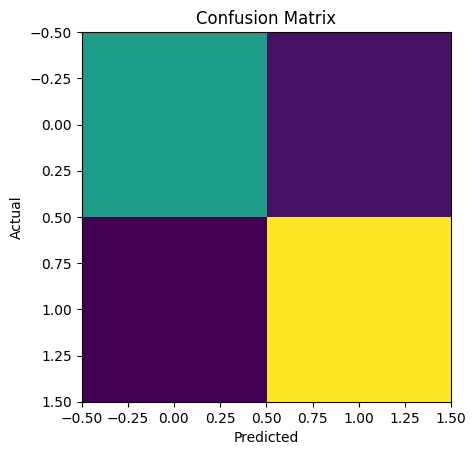

In [17]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       323
           1       0.96      1.00      0.98       531

    accuracy                           0.97       854
   macro avg       0.98      0.96      0.97       854
weighted avg       0.97      0.97      0.97       854



<Figure size 600x500 with 0 Axes>

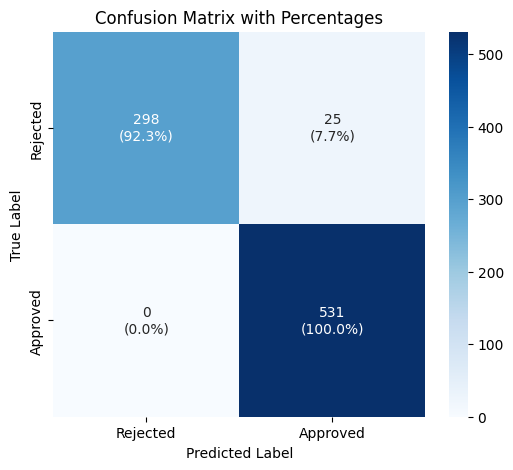

In [19]:
plt.figure(figsize=(6,5))

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(6,5))

labels = np.array([
    [f"{cm[i,j]}\n({cm_percent[i,j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

sns.heatmap(cm,
            annot=labels,
            fmt='',
            cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Percentages")
plt.show()

In [20]:
tree_model = model.named_steps['classifier']

print("عمق واقعی درخت:", tree_model.get_depth())
print("تعداد گره‌ها:", tree_model.tree_.node_count)

عمق واقعی درخت: 4
تعداد گره‌ها: 21


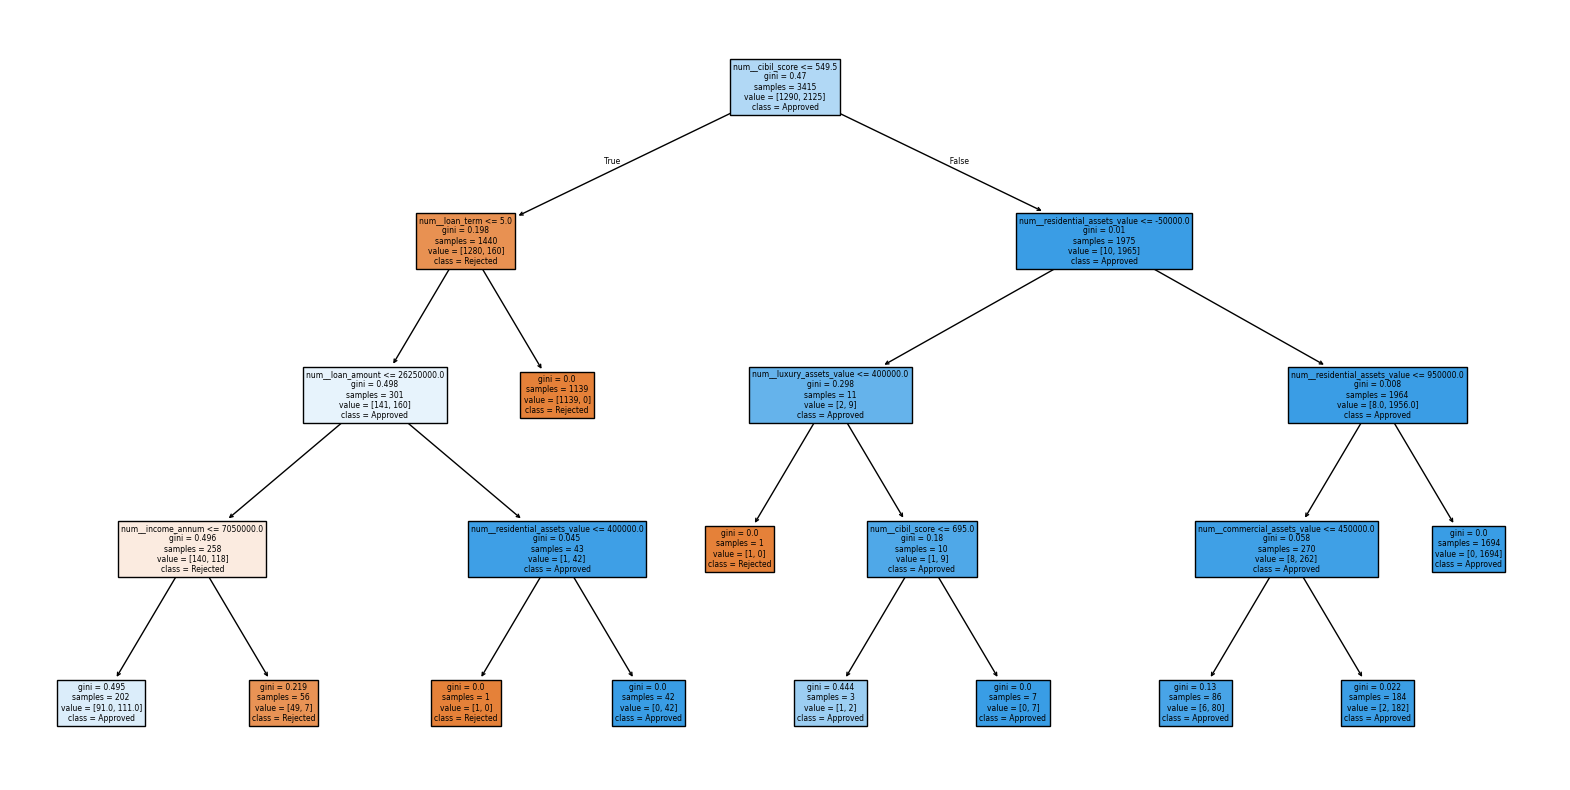

In [21]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Rejected","Approved"],
    filled=True
)
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [0.96955504 0.96135831 0.96604215 0.96018735 0.96365768]
Mean Accuracy: 0.964160107184726
Standard Deviation: 0.0033625169457247367


# Question Two

### Phase 1: Tree training without depth constraints

In [23]:
deep_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=None, random_state=42))
])

deep_model.fit(X_train, y_train)

train_acc = deep_model.score(X_train, y_train)
test_acc = deep_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

tree = deep_model.named_steps['classifier']
print("Tree Depth:", tree.get_depth())
print("Number of Nodes:", tree.tree_.node_count)

Train Accuracy: 1.0
Test Accuracy: 0.9836065573770492
Tree Depth: 15
Number of Nodes: 105


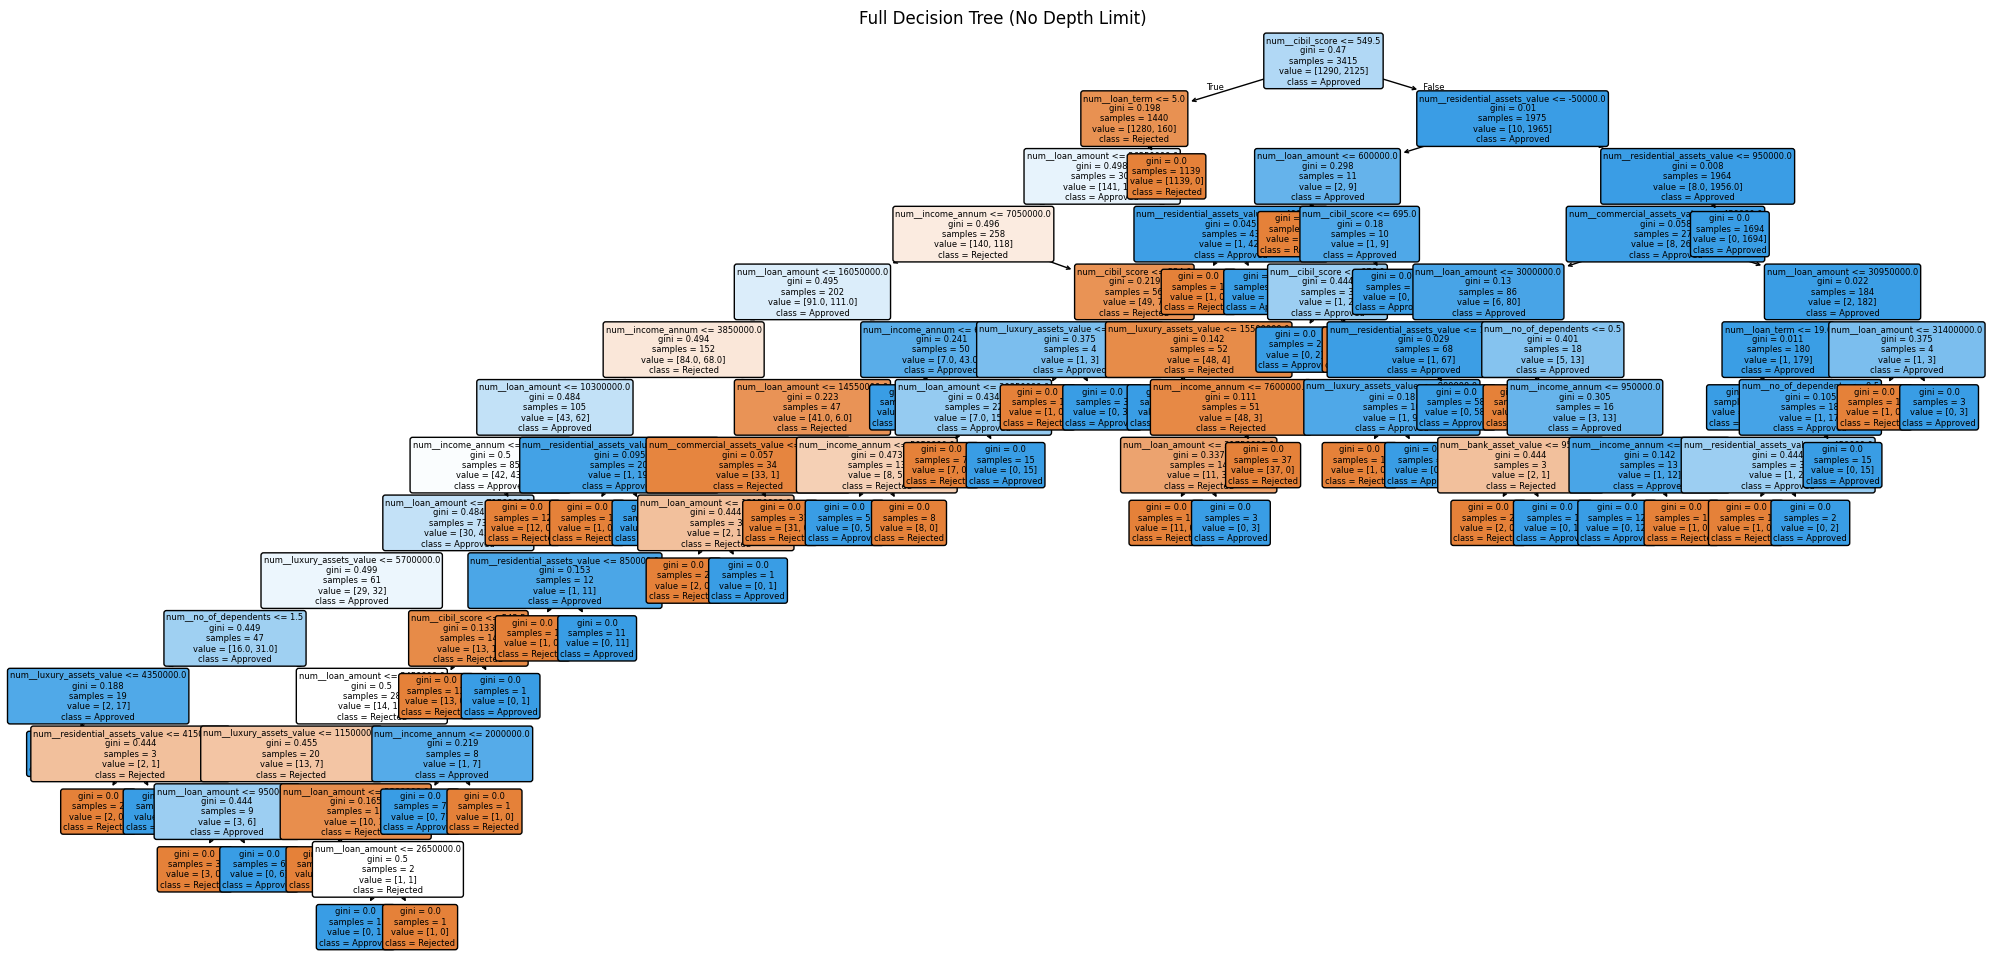

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree = deep_model.named_steps['classifier']
feature_names = deep_model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(25, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Full Decision Tree (No Depth Limit)")
plt.show()

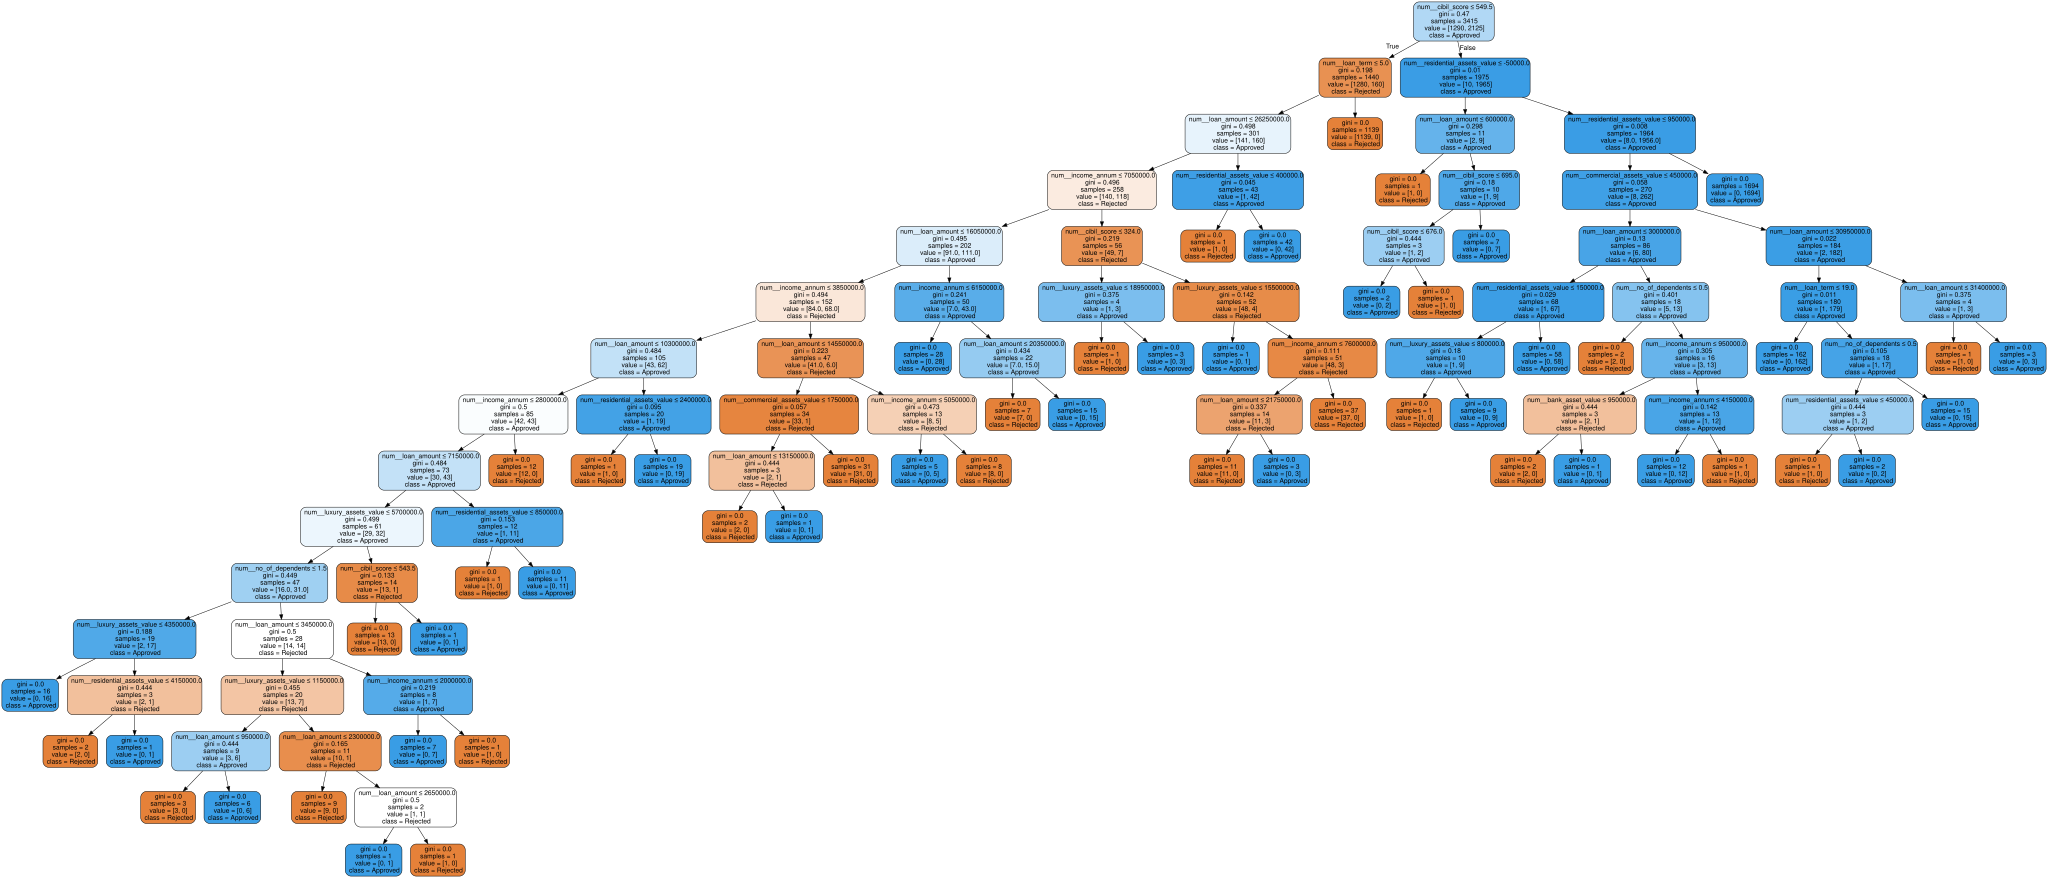

In [25]:

from sklearn.tree import export_graphviz
import graphviz
dot_data = export_graphviz(
    tree,
    feature_names=feature_names,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

### Phase 2: Examining the behavior of the model at different depths

In [26]:
depths = [3, 5, 10, None]

results = []

for d in depths:

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    results.append((d, train_acc, test_acc))

for depth, train_acc, test_acc in results:
    print(f"Depth = {depth}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy : {test_acc:.4f}")
    print("-" * 30)

Depth = 3
  Train Accuracy: 0.9625
  Test Accuracy : 0.9719
------------------------------
Depth = 5
  Train Accuracy: 0.9742
  Test Accuracy : 0.9684
------------------------------
Depth = 10
  Train Accuracy: 0.9950
  Test Accuracy : 0.9801
------------------------------
Depth = None
  Train Accuracy: 1.0000
  Test Accuracy : 0.9836
------------------------------


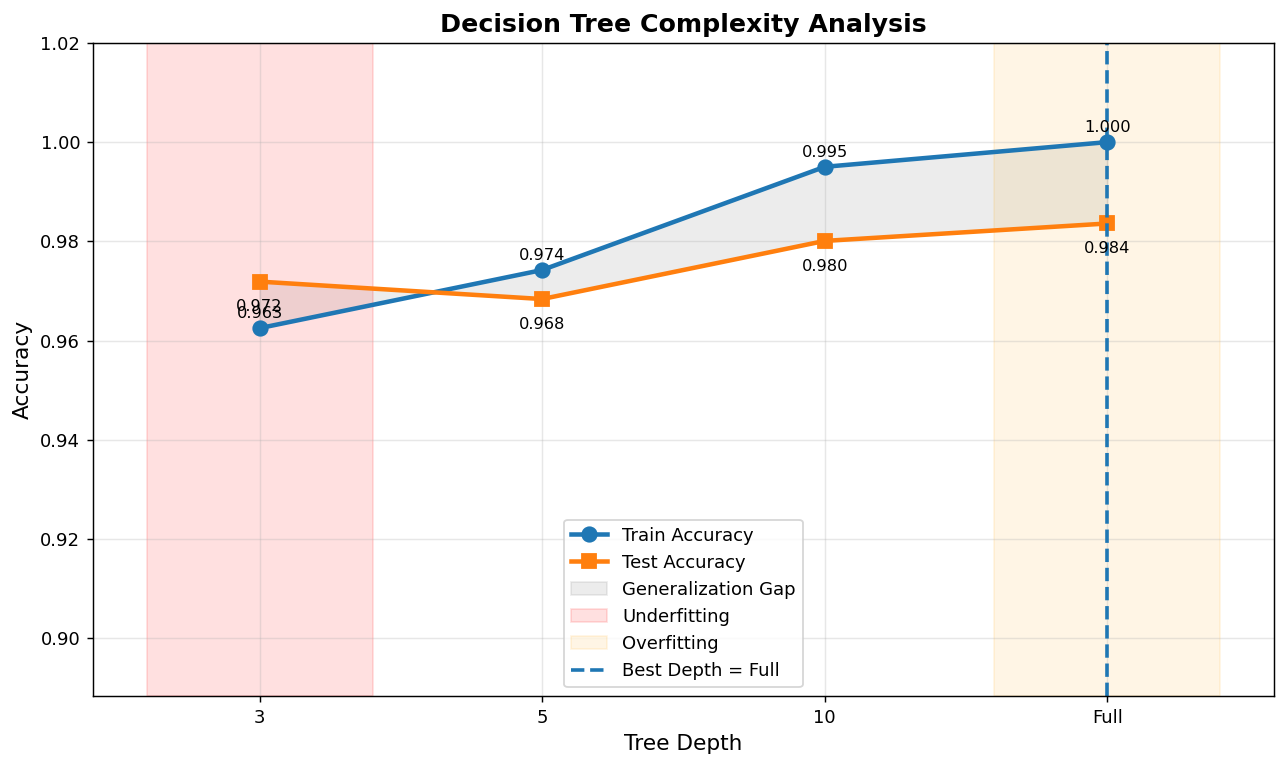

In [27]:
depths = [r[0] for r in results]
train_scores = [r[1] for r in results]
test_scores = [r[2] for r in results]

depth_labels = [str(d) if d is not None else "Full" for d in depths]
x = np.arange(len(depth_labels))

best_index = np.argmax(test_scores)

plt.figure(figsize=(10,6), dpi=130)

plt.plot(x, train_scores, marker='o', linewidth=2.5, markersize=8, label='Train Accuracy')
plt.plot(x, test_scores, marker='s', linewidth=2.5, markersize=8, label='Test Accuracy')

plt.fill_between(x, train_scores, test_scores, color='gray', alpha=0.15, label='Generalization Gap')

if 3 in depths:
    underfit_index = depths.index(3)
    plt.axvspan(underfit_index-0.4, underfit_index+0.4,
                alpha=0.12, color='red', label='Underfitting')

if None in depths:
    overfit_index = depths.index(None)
    plt.axvspan(overfit_index-0.4, overfit_index+0.4,
                alpha=0.10, color='orange', label='Overfitting')

plt.axvline(best_index, linestyle='--', linewidth=2,
            label=f'Best Depth = {depth_labels[best_index]}')

for i, v in enumerate(train_scores):
    plt.text(i, v+0.002, f"{v:.3f}", ha='center', fontsize=9)

for i, v in enumerate(test_scores):
    plt.text(i, v-0.006, f"{v:.3f}", ha='center', fontsize=9)

plt.xticks(x, depth_labels)
plt.xlabel("Tree Depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Decision Tree Complexity Analysis", fontsize=14, weight='bold')

plt.ylim(min(test_scores)-0.08, 1.02)
plt.grid(alpha=0.3)

plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### Phase 3: Cost-Complexity Pruning

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

X_train_processed = preprocessor.fit_transform(X_train)

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(
    X_train_processed, y_train
)

ccp_alphas = path.ccp_alphas
ccp_alphas = ccp_alphas[ccp_alphas > 0]


In [34]:
train_scores = []
test_scores = []
depths = []
nodes = []

for alpha in ccp_alphas:

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            ccp_alpha=alpha
        ))
    ])

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

    tree = model.named_steps['classifier']
    depths.append(tree.get_depth())
    nodes.append(tree.tree_.node_count)


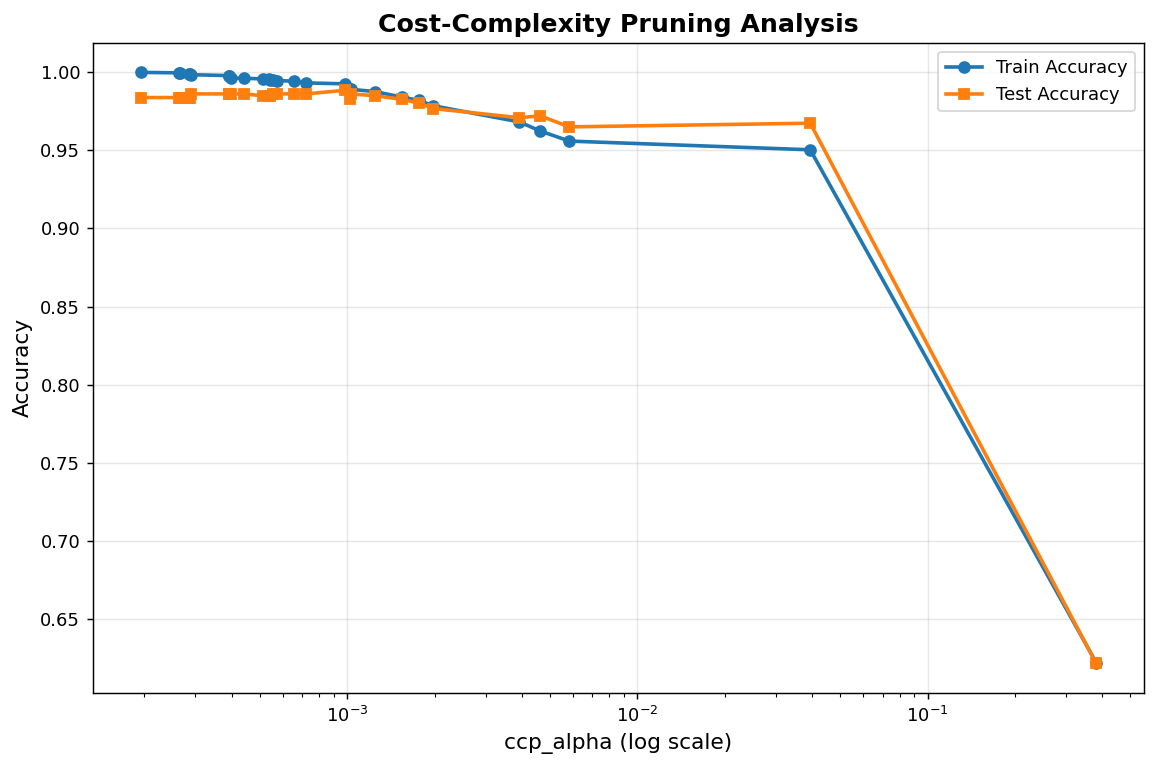

In [35]:
plt.figure(figsize=(9,6), dpi=130)

plt.plot(ccp_alphas, train_scores, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, marker='s', linewidth=2, label='Test Accuracy')

plt.xscale('log')
plt.xlabel("ccp_alpha (log scale)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Cost-Complexity Pruning Analysis", fontsize=14, weight='bold')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
full_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

full_model.fit(X_train, y_train)

full_tree = full_model.named_steps['classifier']
full_depth = full_tree.get_depth()
full_nodes = full_tree.tree_.node_count
full_test_acc = full_model.score(X_test, y_test)

print("Full Tree Depth:", full_depth)
print("Full Tree Nodes:", full_nodes)
print("Full Test Accuracy:", full_test_acc)

Full Tree Depth: 15
Full Tree Nodes: 105
Full Test Accuracy: 0.9836065573770492


In [41]:
best_test = max(test_scores)

selected_index = None

for i in range(len(ccp_alphas)):

    depth_reduction = depths[i] <= 0.7 * full_depth
    node_reduction = nodes[i] <= 0.7 * full_nodes
    acceptable_test = test_scores[i] >= best_test - 0.01

    if depth_reduction and node_reduction and acceptable_test:
        selected_index = i
        break

if selected_index is not None:
    print("\nSelected alpha:", ccp_alphas[selected_index])
    print("Train Accuracy:", train_scores[selected_index])
    print("Test Accuracy:", test_scores[selected_index])
    print("Tree Depth:", depths[selected_index])
    print("Number of Nodes:", nodes[selected_index])
else:
    print("No alpha satisfied all conditions.")


Selected alpha: 0.0010329240440124024
Train Accuracy: 0.9888726207906295
Test Accuracy: 0.9859484777517564
Tree Depth: 10
Number of Nodes: 29


<function matplotlib.pyplot.show(close=None, block=None)>

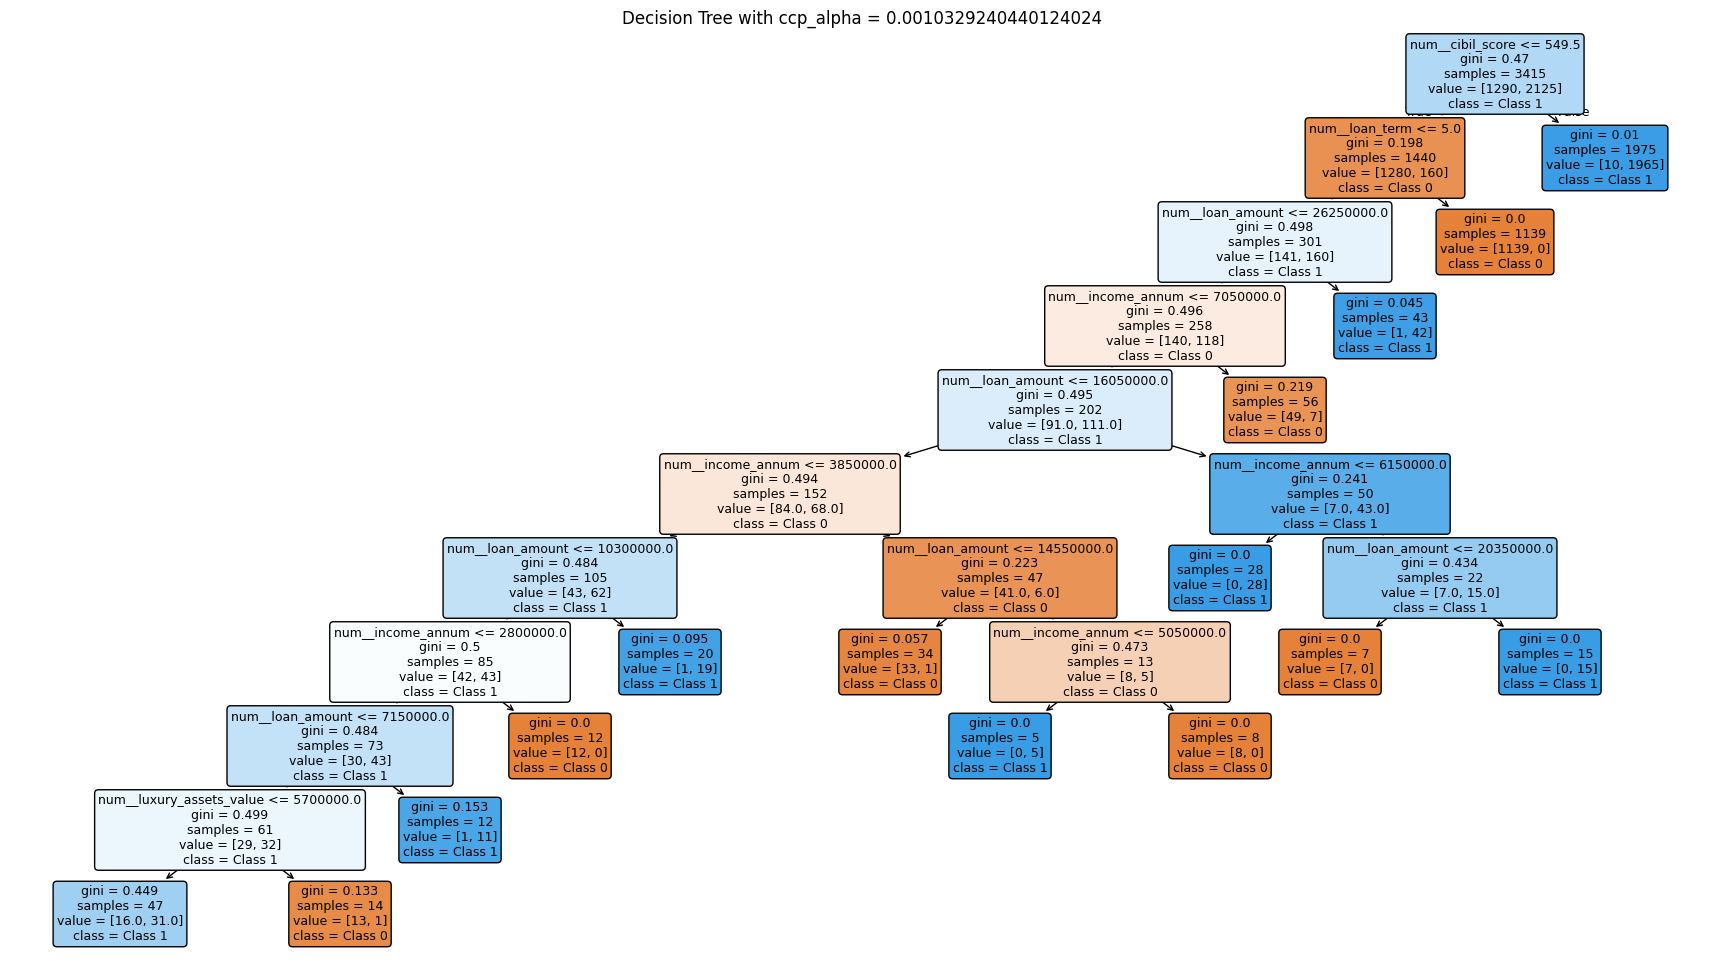

In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_text

alpha = 0.0010329240440124024

pruned_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(ccp_alpha=alpha, random_state=42))
])

pruned_model.fit(X_train, y_train)

tree = pruned_model.named_steps['classifier']

plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    fontsize=9,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['Class 0', 'Class 1']
)
plt.title(f"Decision Tree with ccp_alpha = {alpha}")
plt.show